In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import uniform, loguniform

from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer, brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss
from scipy.stats import uniform

import xgboost as xgb

### How to Make a Custom Scorer

In [31]:
BrierScorer = make_scorer(brier_score_loss, greater_is_better=False, needs_proba=True)

### How to make a custom scorer
def rounded_RMSE(y_true, y_pred):
    rounded_preds = np.round(np.array(y_pred))
    return np.sqrt(np.mean((np.array(y_true) - rounded_preds) ** 2))

rounded_rmse_scorer = make_scorer(rounded_RMSE, greater_is_better=False)

c:\Users\seanv\Anaconda3_old\envs\gpt-env\lib\site-packages\sklearn\metrics\_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


### How to Make a CV Split by Year

In [32]:
import pandas as pd
import os

# Assume root directory is './TrainingData'
root_dir = './TrainingData'

TRAIN_list = []
LABELS_list = []
fold_indices = []

SALE_COLUMNS = ["Actual Loss Calculation", "Zero Balance Removal UPB", "Net Sales Proceeds", 
                "Delinquent Accrued Interest", "Expenses", "MI Recoveries", "Non MI Recoveries"]

MISC_COLUMNS_TO_DROP = ["Metropolitan Statistical Area (MSA) Or Metropolitan Division", 'Postal Code', 
                        'Distress Date', 'Default Flag', 'Zero Balance Code', 'Unresolved', 'Last Time Current',
                         'Property State', 'Current Loan Delinquency Status', 'Loan Sequence Number', 'Start Month']
CAT_COLUMNS = []

fold = 0 

# Load in all files from TrainingData Folder
for year_folder in sorted(os.listdir(root_dir)):
    year_path = os.path.join(root_dir, year_folder)
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                TRAIN_list.append(df.drop(columns=['Major Stress'])) 
                LABELS_list.append(df['Major Stress'])               
                fold_indices.extend([fold] * len(df))
        fold += 1

TRAIN = pd.concat(TRAIN_list).reset_index(drop=True)
TRAIN = TRAIN.drop(columns=SALE_COLUMNS)


In [33]:
TRAIN = TRAIN.drop(columns=MISC_COLUMNS_TO_DROP)
categorical_cols = TRAIN.select_dtypes(include=['object', 'category']).columns.tolist()

# Use below to add columns that we want dummies for but may not current be dtype categorical
# categorical_cols += CAT_COLUMNS

TRAIN = pd.get_dummies(TRAIN, columns=categorical_cols, drop_first=True)
LABELS = pd.concat(LABELS_list).reset_index(drop=True)
LABELS.fillna(0, inplace=True)

ps = PredefinedSplit(test_fold=fold_indices)



### How to Wrap XGB in a SKL Grid Search CVC
Scorer should be something like Brier Score or F1 (needs to account for the ridiculous imabalance and also should make sure probabilities are well calibrated)

In [34]:
state = 42
NumParamSearchIterations = 10

X_train, X_val, y_train, y_val = train_test_split(TRAIN, LABELS, test_size=0.2, random_state=state, stratify=LABELS)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}")

param_distributions = {
    'n_estimators': range(100, 200),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': range(5, 20),
    'subsample': uniform(0, 1),
    'colsample_bytree': uniform(0, 1)
}

hyperparameter_tuning = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=state, 
                      scale_pos_weight=470,
                      objective='binary:logistic',
                      eval_metric='logloss'),
    scoring='neg_brier_score', 
    param_distributions=param_distributions,
    n_iter=NumParamSearchIterations,
    cv=3,
    random_state=state,
    verbose=2,
    n_jobs=6
)

search = hyperparameter_tuning.fit(X_train, y_train)
print("\nBest Hyperparameters:", search.best_params_)
print("Best Average Precision Score (CV on train split):", search.best_score_)
best_model = search.best_estimator_

y_val_pred_probs = best_model.predict_proba(X_val)[:, 1]
ap_score = average_precision_score(y_val, y_val_pred_probs)
brier = brier_score_loss(y_val, y_val_pred_probs)
logloss = log_loss(y_val, y_val_pred_probs)

print("\nValidation Metrics:")
print(f"Average Precision Score: {ap_score:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss: {logloss:.6f}")


Train shape: (1128259, 41), Validation shape: (282065, 41)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Hyperparameters: {'colsample_bytree': 0.3745401188473625, 'learning_rate': 0.2952142919229748, 'max_depth': 15, 'n_estimators': 171, 'subsample': 0.5986584841970366}
Best Average Precision Score (CV on train split): -0.001928228620949252

Validation Metrics:
Average Precision Score: 0.2461
Brier Score: 0.001959
Log Loss: 0.013723


In [36]:
import pandas as pd

results_df = pd.DataFrame({
    'y_true': y_val,
    'y_pred_prob': y_val_pred_probs
})

# Define probability bins
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', 
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
results_df['prob_bin'] = pd.cut(results_df['y_pred_prob'], bins=bins, labels=labels, include_lowest=True)

# Group by bins
bin_summary = results_df.groupby('prob_bin').agg(
    samples=('y_true', 'count'),
    percent=('y_true', lambda x: len(x) / len(results_df) * 100),
    default_rate=('y_true', 'mean')
).reset_index()


print(bin_summary)


  prob_bin  samples    percent  default_rate
0    0-0.1   281343  99.744031      0.001326
1  0.1-0.2      190   0.067360      0.136842
2  0.2-0.3       82   0.029071      0.170732
3  0.3-0.4       63   0.022335      0.126984
4  0.4-0.5       39   0.013827      0.205128
5  0.5-0.6       41   0.014536      0.219512
6  0.6-0.7       42   0.014890      0.333333
7  0.7-0.8       41   0.014536      0.414634
8  0.8-0.9       63   0.022335      0.444444
9  0.9-1.0      161   0.057079      0.577640


C:\Users\seanv\AppData\Local\Temp\ipykernel_33976\2275752112.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = results_df.groupby('prob_bin').agg(


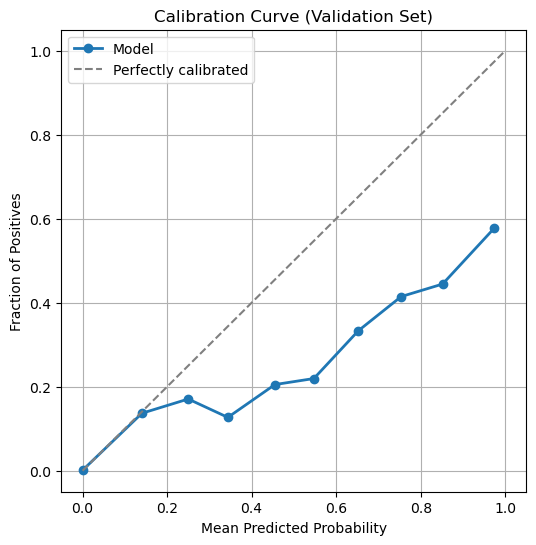

In [37]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Compute calibration curve
# (true labels, predicted probabilities, and number of bins)
true_probs, pred_probs = calibration_curve(y_val, y_val_pred_probs, n_bins=10, strategy='uniform')

# Plot
plt.figure(figsize=(6, 6))
plt.plot(pred_probs, true_probs, marker='o', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.title('Calibration Curve (Validation Set)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()
